# 1. Import

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR,
 CLAUDE_CLADE_DIR, TREE_NWK,

    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


/datadrive/fangtq/HiC-DNA


In [10]:

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from dataset.track_loader import Track_Loader
from config import tracks

from plot_settings import colors as candidate_colors
from plot_utils import plot_box_with_points

import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


In [11]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


In [12]:
L, R = 1000, 1500
sL, sR = L*2000, R*2000

# 3. Epigenomics

In [13]:
tls = [
    Track_Loader(str(HIC2TRACK('GM12878')), 2000),
]
gts = []
for tl in tls:
    gts.append(tl.get(9, 0, (tl.chr_lens['chr9']//2000+1)*2000, 0))

data/hic2track/GM12878
0.0364 0.07343012021471802
0.03516 0.058822779373849575
0.03607 0.105951909994905
0.02351 0.02145021099161991
0.04712 0.13544065389145613


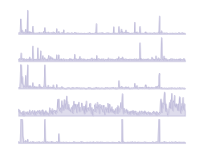

In [14]:
track_names = list(tracks.keys())

color = candidate_colors[1]

idx = 1
target = list(tracks.keys())[idx]

# Make a compressed figure with small vertical heights
fig, axes = plt.subplots(
    5, 1, figsize=(1.97, 1.5), 
    gridspec_kw={'height_ratios': [1, 1, 1, 1, 1], 'hspace': 0.05}  # equal thin height, smaller spacing
)

for i in range(5):
    axes[i].plot(range(L, R), gts[0][i, L:R], color=color, linewidth=0.3)
    axes[i].fill_between(
        x=range(L, R), 
        y1=gts[0][i, L:R],
        color=color,
        alpha=0.5
    )
    # if i !=3:
    #     axes[i].set_ylim(0, 1)
    # else:
    #     axes[i].set_ylim(0, 0.2)

    # axes[i].text(
    #     0.03,
    #     0.6,
    #     track_names[i],
    #     transform = axes[i].transAxes,
    #     fontsize='small',
    #     ha='left',
    #     va='bottom'
    # )

    # Remove x-axis for all but last track
    axes[i].set_xticks([])
    axes[i].spines['bottom'].set_visible(False)

    # Remove all borders (top, left, right)
    axes[i].spines['left'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)

    # Optional: remove y-ticks if you want super clean
    axes[i].set_yticks([])

# Adjust only the last subplot x-axis label
# axes[-1].set_xlabel("Genomic position")

plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.05)  # tighter layout control
fig.savefig(str(OUT_DIR / 'Fig1_epigenomics.pdf'))

# Hi-C

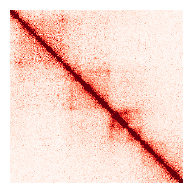

In [15]:
from dataset.hic_loader import HiC_Loader
hic_loader = HiC_Loader(str(HIC_RAW('4DNFI1UEG1HD')), 2000)

sL, sR = 6000000, 7000000
fig = plt.figure(figsize=(1.97, 1.97))
ax = fig.add_subplot(1,1,1)

matrix = hic_loader.get(9, sL, sR, 0, 9, sL, sR, 0, norm=True)[0]
# matrix = np.log1p(matrix)
vmin, vmax = 0, 20

im = ax.imshow(matrix, cmap='Reds', origin='upper', vmin=vmin, vmax=vmax, interpolation='none')
ax.axis('off')
# T_Mp2 — colour bar (reviewer-asked)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.set_label('contacts (raw count)', fontsize=6)
cb.outline.set_linewidth(0.4)
cb.ax.tick_params(length=2, labelsize=5)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

fig.tight_layout()
fig.savefig(str(OUT_DIR / 'Fig1_HiC.pdf'), bbox_inches='tight', pad_inches=0)


# DNA

In [16]:
from dataset.DNA_loader import DNA_Loader
dna_loader = DNA_Loader(str(DNA_FASTA['human']))
dna = dna_loader.get(9, sL, sR, 0)
base_code = ['A', 'C', 'G', 'T']
s = ''
for i in range(dna.shape[0]):
    for j in range(5):
        if j==4:
            s+='N'
            break
        if dna[i,j]:
            s+=base_code[j]
            break
    if i>100:
        break
s

'TATTAACTTCCTTTCAATAAAATACATTTTTAATATAAAAGTAATATGCTTATTGTAGAATATCTAGGACATATAGAAAAGTTAAAAGAAGAAAATGAAAAC'